# Проект. Исследование стартапов

## Введение

- Автор: Камалов Тимур
- Дата: 15.04.2026

Целью работы является проведение исследования по динамике и структуре финансирования стартапов до 2014 года, чтобы подготовить рекомендации для дальнейшего финансирования если бы на дворе был 2015.


## Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

In [1]:
# Загружаем и импортируем необходимые библиотеки
!pip install phik
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik

     |████████████████████████████████| 677 kB 2.5 MB/s eta 0:00:01


In [2]:
# Считываем датасет cb_investments
cb_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
# Считываем датасет cb_returns
cb_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

In [4]:
# Выводим основную информацию по cb_investments
print(f"Размер датасета cb_investments: {cb_investments.shape}")
print()
print("Первые строки датасета:")
pd.set_option('display.max_columns', None)
display(cb_investments.head(15))
print()
print("Информация о датасете:")
print(cb_investments.info())

Размер датасета cb_investments: (54294, 40)

Первые строки датасета:


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Xavier University,http://www.xavier.edu/,NaN,NaN,"1,90,00,000",operating,USA,OH,Cincinnati,Cincinnati,1.0,NaN,1831-01-01,NaN,NaN,1831.0,2014-10-23,NaN,2014-10-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Tulane University,http://tulane.edu/,|Education|,Education,"1,20,00,000",operating,USA,LA,New Orleans,New Orleans,4.0,0.0,1834-01-01,NaN,NaN,1834.0,2013-09-05,2013-09-05,2013-12-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Duke University,http://www.duke.edu,|Education|,Education,"87,00,000",operating,USA,NC,Raleigh,Durham,1.0,NaN,1838-01-01,NaN,NaN,1838.0,2014-01-12,NaN,2014-01-12,0.0,8700000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,"Virginia Commonwealth University, Richmond",http://www.vcu.edu/,NaN,NaN,"60,00,000",operating,USA,VA,Richmond,Richmond,1.0,NaN,1838-01-01,NaN,NaN,1838.0,2014-09-30,NaN,2014-09-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,WeGame,http://www.WeGame.com,|Social Media|,Social Media,"35,00,000",acquired,USA,CA,SF Bay Area,San Francisco,2.0,2.0,1840-01-01,NaN,NaN,1840.0,2007-10-01,2007-10-01,2008-03-01,500000.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 


In [5]:
# Выводим пропуски в абсолютных и относительных значениях
pd.DataFrame({
    'absolute': cb_investments.isna().sum(),
    'percent': (cb_investments.isna().sum() / len(cb_investments) * 100).round(2)
})

,absolute,percent
name,4857,8.95
homepage_url,8305,15.30
category_list,8817,16.24
market,8817,16.24
funding_total_usd,4856,8.94
status,6170,11.36
country_code,10129,18.66
state_code,24133,44.45
region,10129,18.66
city,10972,20.21


In [6]:
# Выводим основную информацию по cb_returns
print(f"Размер датасета cb_returns: {cb_returns.shape}")
print()
print("Первые строки датасета:")
display(cb_returns.head())
print()
print("Информация о датасете:")
print(cb_returns.info())

Размер датасета cb_returns: (15, 14)

Первые строки датасета:


,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB
None


In [7]:
# Выводим пропуски в абсолютных и относительных значениях
pd.DataFrame({
    'absolute': cb_returns.isna().sum(),
    'percent': (cb_returns.isna().sum() / len(cb_investments) * 100).round(2)
})

,absolute,percent
year,0,0.0
seed,0,0.0
venture,0,0.0
equity_crowdfunding,0,0.0
undisclosed,0,0.0
convertible_note,0,0.0
debt_financing,0,0.0
angel,0,0.0
grant,0,0.0
private_equity,0,0.0


Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Датасет `cb_investments` содержит 54294 строки на 40 столбцов - данные о компаниях.

**Типы данных**.

- Необходимо изменить типы данных в столбцах, `first_funding_at`, `mid_funding_at`, `last_funding_at`, они отображают даты и для корректной дальнейшей работы их необходимо перевести в тип `datetime`. Столбец `founded_at` можно оставить типом `object`, так как он содержит периоды, которые pandas не может корректно перевести в формат `datetime` и для дальнейшей работы подойдет столбец 
- Также в столбце `funding_total_usd` необходимо убрать разделитель разрядности `,` и заменить тип данных `object` на `Int64`.

- Столбцы, где речь идет о суммах, а именно: `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market`, `product_crowdfunding` и `round_A — round_H` хранятся в формате `float64` из-за того, что pandas не может хранить числа с пропусками в целочисленном формате `Int64`. Изменять типы в данном случае не обязательно, так как суммы инвестиций в долларах могут корректно храниться в `float64` и для математических операций тип не важен.

**Пропуски**.

Пропущенные значения обнаружены во всех столбцах. Наибольшее число таковых содержатся в `state_code` (44.4%), `mid_funding_at` (44.2%), `participants` (43.9%), в `founded_month` и `founded_quarter` по 29.1%, при этом столбцы с суммами содержат одинаковое количество пропусков (8.9%), на что стоит обратить внимание в будущем.

**Особенности**.

К особенностям можно отнести то, что два столбца `market` и  `funding_total_usd` имеют лишний пробел в начале названия, их требуется привести к нормальной форме.


Датасет `cb_returns` содержит 15 строк на 14 столбцов - данные по годам с 2000 по 2014.

**Типы данных**.

Все типы данных в данном датасете представлены верно.

**Пропуски**.

Пропусков в данном датасете не обнаружено.

**Особенности**.

Особенностей не обнаружено.

In [8]:
# Приводим названия столбцов к единому стилю

cb_investments.columns = cb_investments.columns.str.strip()
cb_investments.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [9]:
# Преобразовываем funding_total_usd

cb_investments['funding_total_usd'] = cb_investments['funding_total_usd'].str.replace(',','')
cb_investments['funding_total_usd'] = pd.to_numeric(cb_investments['funding_total_usd'],errors='coerce')
cb_investments['funding_total_usd'] = cb_investments['funding_total_usd'].astype('Int64')
cb_investments['funding_total_usd'].dtypes

Int64Dtype()

In [10]:
# Преобразовываем столбцы к datetime64

for i in ['first_funding_at', 'mid_funding_at', 'last_funding_at']:
    cb_investments[i] = pd.to_datetime(cb_investments[i],errors='coerce')
    print(cb_investments[i].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]


In [11]:
# Делаем столбец year индексом

cb_returns = cb_returns.set_index('year')
cb_returns

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [12]:
# Обрабатываем текстовые данные

object_cols = ['name', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']

before = 0
for i in object_cols:
    before += cb_investments[i].nunique()
    
for i in object_cols:
    cb_investments[i] = cb_investments[i].str.strip().str.lower()

after = 0
for i in object_cols:
    after += cb_investments[i].nunique()
    
print(f'до нормализации {before}, после: {after}, разница {before - after}')
    
for i in ['country_code', 'status']:
    cb_investments[i] = cb_investments[i].fillna('unknown')

до нормализации 72420, после: 71901, разница 519


In [13]:
# Обрабатываем полные дубликаты

print('Количество полных дубликатов:')
print(cb_investments.duplicated().sum())
cb_investments = cb_investments.drop_duplicates()

print(cb_investments['funding_total_usd'].isna().sum())

cb_investments = cb_investments.dropna(subset=['funding_total_usd'])

print(cb_investments['funding_total_usd'].isna().sum())


print('Количество полных дубликатов после удаления:')
print(cb_investments.duplicated().sum())

Количество полных дубликатов:
4855
8532
0
Количество полных дубликатов после удаления:
0


In [14]:
# Обрабатываем пропуски

print('Количество пропусков до обработки:')
print(cb_investments['mid_funding_at'].isna().sum())

mean_interval = cb_investments['first_funding_at'] + (cb_investments['last_funding_at'] - cb_investments['first_funding_at']) / 2
cb_investments['mid_funding_at'] = cb_investments['mid_funding_at'].fillna(mean_interval)

print('Количество пропусков после обработки:')
print(cb_investments['mid_funding_at'].isna().sum())

Количество пропусков до обработки:
13676
Количество пропусков после обработки:
1


In [15]:
# Оцениваем полноту данных

print(54294 - cb_investments.shape[0], ((54294 - cb_investments.shape[0]) / 54294) * 100)
print(cb_investments.shape[0])

13387 24.656499797399345
40907


In [16]:
# Выводим пропуски после предобработки

cb_investments.isna().sum()

name                        1
homepage_url             2314
category_list            2503
market                   2503
funding_total_usd           0
status                      0
country_code                0
state_code              15288
region                   3819
city                     4505
funding_rounds              0
participants            13576
founded_at               8706
founded_month            8772
founded_quarter          8772
founded_year             8706
first_funding_at            2
mid_funding_at              1
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_A                     0
round_B   

**Вывод по предобработке**

В ходе предобработки выполнены следующие шаги:
- Исправлены названия столбцов `market` и  `funding_total_usd` (удалены лишние пробелы).
- Столбец `funding_total_usd` очищен от символов-разделителей и приведён к числовому типу.
- Необходимые столбцы с датами приведены к типу datetime.
- Столбец `year` датасета cb_returns стал индексом.
- Пропуски в текстовых столбцах (`country_code`, `status`) заполнены заглушкой `unknown`.
- Путем нормализации текстовых столбцов были обработаны 18 неявных дубликатов.
- Удалены полные дубликаты и строки без данных о финансировании.
- Пропуски в `mid_funding_at` восстановлены как середина интервала между первым и последним раундами.

Удалено около **24.7%** строк, только те, что не содержали информации о финансировании или являлись дубликатами. Оставшихся данных достаточно для проведения полноценного анализа.

Итоговый размер датасет `cb_investments` после предобработки: 40907 на 40

In [17]:
# Категоризируем компании

def fin_term(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    if (row['last_funding_at'] - row['first_funding_at']).days <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'
    
cb_investments['fin_group'] = cb_investments.apply(fin_term,axis=1)
print(cb_investments['fin_group'].value_counts())

Единичное финансирование          24113
Срок финансирования более года    12293
Срок финансирования до года        4501
Name: fin_group, dtype: int64


In [18]:
# Оцениваем доли в каждой категории

fin_count_bar = cb_investments['fin_group'].value_counts() * 100 / len(cb_investments['fin_group'])
fin_count_bar

Единичное финансирование          58.945902
Срок финансирования более года    30.051092
Срок финансирования до года       11.003007
Name: fin_group, dtype: float64

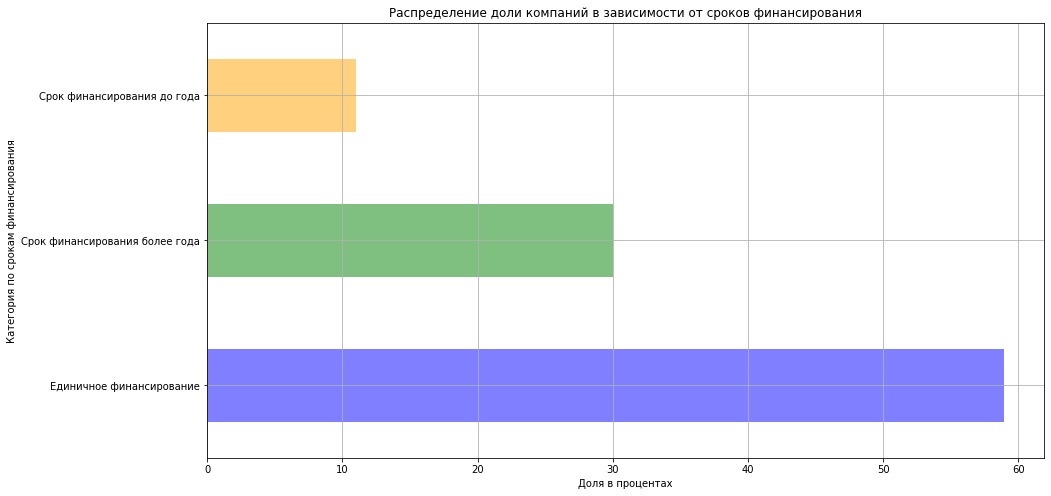

In [19]:
# Строим горизонтальную столбчатую диаграмму

colors = ['blue', 'green', 'orange']

(cb_investments['fin_group'].value_counts() * 100 / len(cb_investments['fin_group'])).plot(
    kind='barh',
    title='Распределение доли компаний в зависимости от сроков финансирования',
    figsize=(15,8),
    color=colors,
    alpha=0.5,
    grid=True)

plt.ylabel('Категория по срокам финансирования')
plt.xlabel('Доля в процентах')

plt.show()

In [20]:
# Оцениваем доли в каждой категории

vol_invest = cb_investments.groupby('fin_group')['funding_total_usd'].sum().sort_values(ascending=False)

vol_invest_bar = vol_invest * 100 /sum(cb_investments['funding_total_usd'])
vol_invest_bar

fin_group
Срок финансирования более года    61.871631
Единичное финансирование          30.618237
Срок финансирования до года        7.510132
Name: funding_total_usd, dtype: Float64

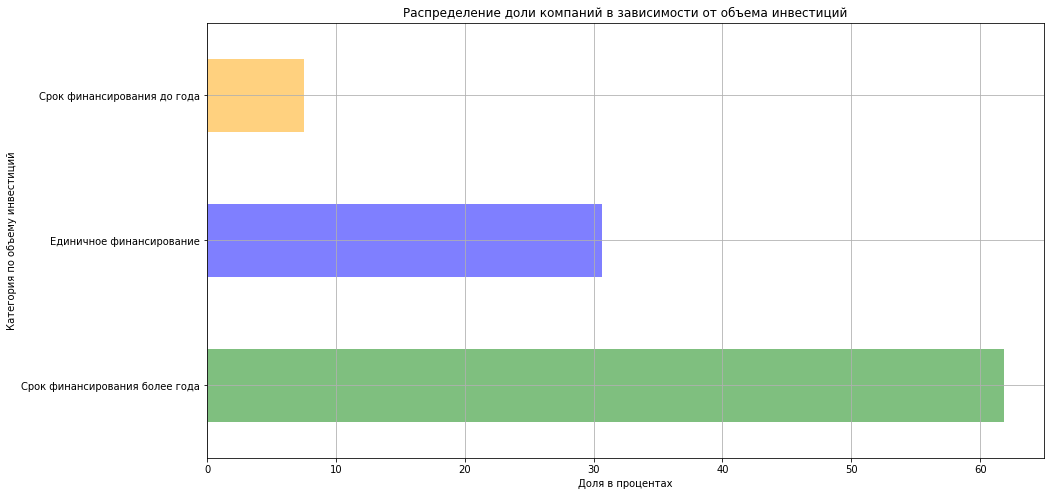

In [21]:
# Строим горизонтальную столбчатую диаграмму

colors = ['green', 'blue', 'orange']

vol_invest_bar.plot(
    kind='barh',
    title='Распределение доли компаний в зависимости от объема инвестиций',
    figsize=(15,8),
    color=colors,
    alpha=0.5,
    grid=True)

plt.ylabel('Категория по объему инвестиций')
plt.xlabel('Доля в процентах')
plt.show()

Большинство компаний **(59%)** ограничивались `единичным финансированием` и при этом в доле объемов инвестиций ограничиваются лишь **30%**, когда компании, которые финансировались `более года`, что в процентном соотношении составляет **30%** забрали себе **более 60%** общей доли инвестиций. Это говорит о том, большое количество стартапов не могут впоследствии привлечь повторные инвестиции и первичные инвестиции не всегда самые крупные. Стартапы, которые смогли получить инвестиции сразу в нескольких раундах выглядят более надежно для инвесторов, что и отражается в объемах инвестиций этой категории. Для заказчика это означает, что нужно в первую очередь рассматривать направления, которые смогли привлечь неоднократные инвестиции, так как они пользуются большим доверием у инвесторов и соответственно привлекают больше средств.

In [22]:
# Расставляем категории сегментам

mrkt_counts = cb_investments['market'].value_counts()

def market_segments(row):
    if row > 120:
        return 'массовый'
    elif row >= 35:
        return 'средний'
    else:
        return 'нишевый'
    
mrkt_segment = mrkt_counts.apply(market_segments)
mrkt_segment.value_counts()

нишевый     289
средний      57
массовый     48
Name: market, dtype: int64

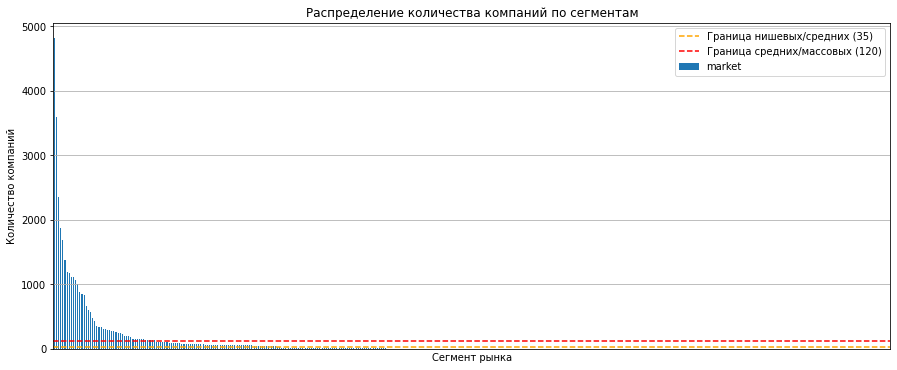

In [23]:
# Строим столбчатую диаграмму

mrkt_counts.plot(
    kind='bar',
    figsize=(15, 6),
    title='Распределение количества компаний по сегментам',
    grid=True)

plt.axhline(y=35, color='orange', linestyle='--', label='Граница нишевых/средних (35)')
plt.axhline(y=120, color='red', linestyle='--', label='Граница средних/массовых (120)')

plt.xlabel('Сегмент рынка')
plt.ylabel('Количество компаний')
plt.xticks([])
plt.legend()
plt.show()

In [24]:
# Оставляем только массовые сегменты

def market_mass(market_name):
    if pd.isna(market_name):
        return float('NaN')
    count = mrkt_counts[market_name]
    if count < 35:
        return 'niche'
    elif count <= 120:
        return 'mid'
    else:
        return market_name

cb_investments['market'] = cb_investments['market'].apply(market_mass)
cb_investments['market'].unique()

array(['education', nan, 'mid', 'social media', 'hardware + software',
       'biotechnology', 'hospitality', 'enterprise software',
       'manufacturing', 'finance', 'design', 'niche', 'nonprofits',
       'software', 'curated web', 'health care', 'health and wellness',
       'clean technology', 'web hosting', 'e-commerce', 'automotive',
       'medical', 'fashion', 'security', 'networking', 'analytics',
       'semiconductors', 'public relations', 'travel', 'consulting',
       'real estate', 'technology', 'music', 'advertising', 'games',
       'mobile', 'internet', 'sports', 'photography', 'news', 'search',
       'messaging', 'video', 'marketplaces', 'entertainment', 'saas',
       'cloud computing', 'big data', 'apps', 'social network media',
       'startups'], dtype=object)

В датасете обнаружено **394 сегмента рынка**. Большинство из них — **289 нишевых** (менее 35 компаний), **57 средних** (от 35 до 120 компаний) и **48 массовых** (более 120 компаний). 

График распределения наглядно показывает, что несколько самых популярных сегментов концентрируют в себе несколько тысяч компаний, а оставшееся большинство сегментов ограничиваются десятками или единицами. Для дальнейшего анализа нишевые и средние сегменты объединены в группы `niche` и `mid`, а массовые сегменты (**48**) были оставлены без изменений и именно они представляют наибольший интерес для анализа рынка.

In [25]:
# Выводим описание funding_total_usd

print(cb_investments['funding_total_usd'].describe().astype('int64'))

count          40907
mean        15912526
std        168678800
min                1
25%           350000
50%          2000000
75%         10000000
max      30079503000
Name: funding_total_usd, dtype: int64


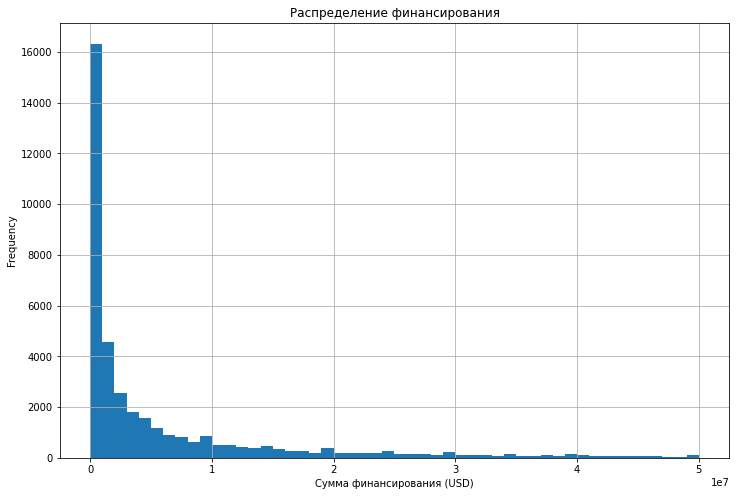

In [26]:
# Строим гистограмму

cb_investments[cb_investments['funding_total_usd'] <= 50000000]['funding_total_usd'].plot(
    kind='hist',
    figsize=(12, 8),
    title='Распределение финансирования',
    bins=50,
    grid=True)

plt.xlabel('Сумма финансирования (USD)')
plt.show()

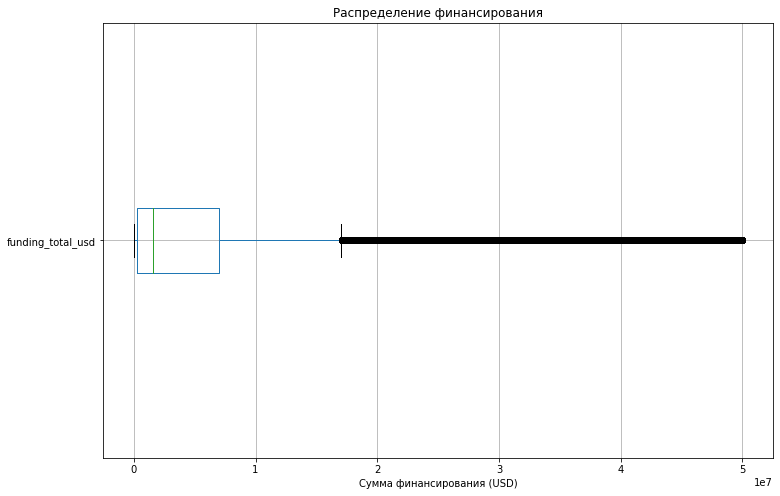

In [27]:
# Строим ящик с усами

cb_investments[cb_investments['funding_total_usd'] <= 50000000]['funding_total_usd'].plot(
    kind='box',
    figsize=(12, 8),
    title='Распределение финансирования',
    vert=False,
    grid=True)

plt.xlabel('Сумма финансирования (USD)')
plt.show()

In [28]:
# Выводим количество аномалий

def segment_anomaly(segment):
    q1 = segment['funding_total_usd'].quantile(0.25)
    q3 = segment['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    higher = q3 + 1.5 * iqr
    return segment[(segment['funding_total_usd'] < lower) | (segment['funding_total_usd'] > higher)]

cb_anomaly = cb_investments.groupby('market').apply(segment_anomaly)

print(f'Количество аномальных компаний: {len(cb_anomaly)}')

Количество аномальных компаний: 4871


In [29]:
# Выводим категории с наибольшей долей аномалий

total_segment_sum = cb_investments.groupby('market')['funding_total_usd'].count()

cb_anomaly = cb_anomaly.reset_index(drop=True)
anomaly_segment_sum = cb_anomaly.groupby('market')['funding_total_usd'].count()

anomaly_share = (anomaly_segment_sum / total_segment_sum * 100).round(2).sort_values(ascending=False)

print(anomaly_share.head(10))

market
real estate        17.20
entertainment      16.67
consulting         16.62
search             16.49
cloud computing    16.45
saas               16.18
photography        16.18
technology         15.97
video              15.96
niche              15.90
Name: funding_total_usd, dtype: float64


Распределение финансирования исходя из гистограммы и ящика с усами имеет большой `правый хвост`, большинство стартапов получили относительно небольшое финансирование, тогда как единичные исключения - огромные суммы. `Медианное значение` составляет **2млн USD**, тогда как `среднее значение` равно **15.9млн USD**, что говорит о значительных выбросах. `Интерквартильный размах` расположен **от 350тыс. USD до 10млн. USD**. `Минимум` - **1 USD**, `максимум` - **более 30млрд. USD** - эти значения являются очевидными выбросами. К `аномальным финансированиям` по сегментам относятся **4871 записей**, что является примерно **12%** от общего объема датасета. Среди сегментов по доли аномальных финансирований лидируют `real estate` **(17.2%)**, `entertainment` **(16.67%)** и `consulting` **(16.62%)**. Доля в топ-10 варьируется от **15.9%** до **17.2%**, что говорит о примерно равномерном распределении аномалий по рынку. Для заказчика следует ориентироваться на медианные значения инвестиций и учитывать, что выбросы могут искажать реальную картину при выборе сегмента.

In [30]:
# Количество раундов по месяцам

round_2014_months = cb_investments[cb_investments['mid_funding_at'].dt.year == 2014]['mid_funding_at'].dt.month.value_counts().sort_index()
print(round_2014_months)

1     739
2     600
3     676
4     645
5     600
6     740
7     687
8     559
9     547
10    497
11    306
12     23
Name: mid_funding_at, dtype: int64


In [31]:
# Выводим количество пропусков столбца market

print(cb_investments['market'].isna().sum())

2503


In [32]:
# Оставляем только компании которые не являются аномальными
def not_anomaly(segment):
    q1 = segment['funding_total_usd'].quantile(0.25)
    q3 = segment['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    higher = q3 + 1.5 * iqr
    return segment[(segment['funding_total_usd'] >= lower) & (segment['funding_total_usd'] <= higher)]

cb_investments = cb_investments.groupby('market').apply(not_anomaly).reset_index(drop=True)
print(cb_investments.shape)

(33533, 41)


In [33]:
# Выводим количество раундов по годам

rounds_by_year = cb_investments.groupby(cb_investments['mid_funding_at'].dt.year)['funding_rounds'].sum()
print(rounds_by_year)

mid_funding_at
1960.0        2.0
1979.0        1.0
1984.0        2.0
1987.0        1.0
1989.0        1.0
1990.0        1.0
1992.0        2.0
1993.0        1.0
1994.0        3.0
1995.0        9.0
1996.0        8.0
1997.0        5.0
1998.0       15.0
1999.0       41.0
2000.0      109.0
2001.0       58.0
2002.0       97.0
2003.0      120.0
2004.0      169.0
2005.0      931.0
2006.0     1825.0
2007.0     2820.0
2008.0     3624.0
2009.0     4472.0
2010.0     5975.0
2011.0     7368.0
2012.0     9312.0
2013.0    12320.0
2014.0     6343.0
Name: funding_rounds, dtype: float64


In [34]:
# Выводим объем датасета после отбрасывания аномалий

cb_investments = cb_investments[
    (cb_investments['mid_funding_at'].dt.year >= 2000) & 
    (cb_investments['mid_funding_at'].dt.year <= 2014)
]
print(cb_investments.shape)

(33473, 41)


Данные за 2014 год являются неполными, записей за декабрь по столбцу `mid_funding_at` содержится всего 23 против 306-740 записей за остальные месяцы, следовательно можно полагать, что данные заполнялись вплоть до начала декабря 2014 года, в дальнейшем это нужно будет учитывать. В процессе обработки данных с аномальным финансированием было удалено 7374 записи, 4871 записей - аномальное финансирование, 2503 - пропуски столбца `market`, которые не попали в обработанный датасет - они будут бесполезны, так как не содержат информацию о сегментах в принципе.
После фильтрации по годам с 50 или более раундами финансирования остались года 2000–2014 и итоговый датасет стал объемом 33 473 строки.

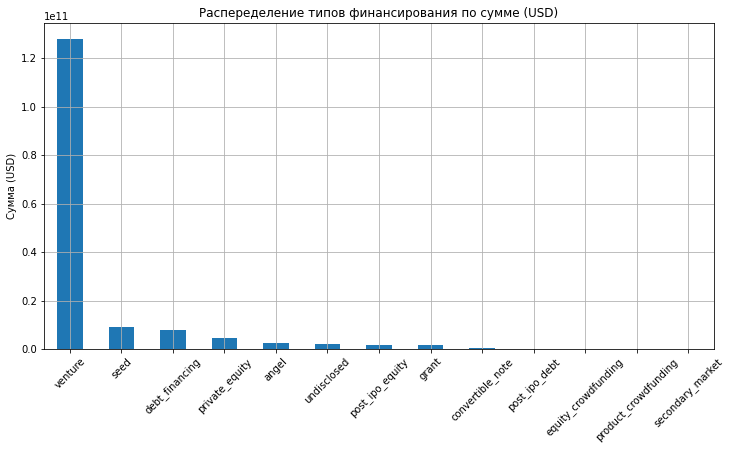

In [35]:
# Строим столбчатую диаграмму

fin_columns = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
               'convertible_note', 'debt_financing', 'angel', 'grant',
               'private_equity', 'post_ipo_equity', 'post_ipo_debt',
               'secondary_market', 'product_crowdfunding']

fin_sum = cb_investments[fin_columns].sum().sort_values(ascending=False)
fin_sum.plot(
    kind='bar',
    figsize=(12, 6),
    title='Распеределение типов финансирования по сумме (USD)',
    grid=True,
    rot=45)
plt.ylabel('Сумма (USD)')
plt.show()

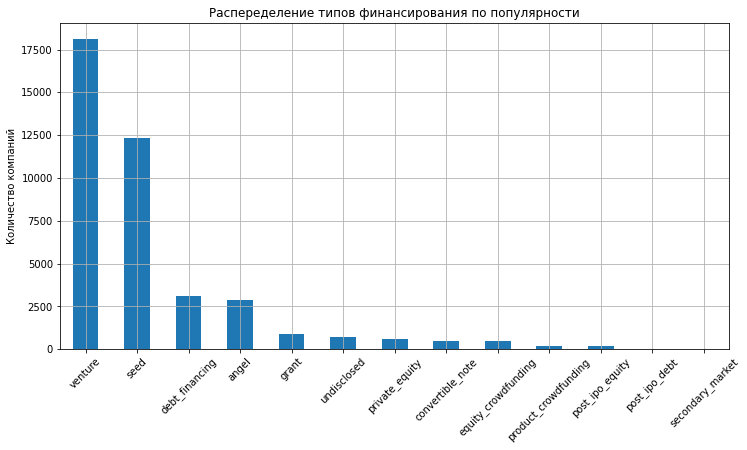

In [36]:
# Строим столбчатую диаграмму

fin_count = (cb_investments[fin_columns] > 0).sum().sort_values(ascending=False)
fin_count.plot(
    kind='bar',
    figsize=(12, 6),
    title='Распеределение типов финансирования по популярности',
    grid=True,
    rot=45)
plt.ylabel('Количество компаний')
plt.show()

In [37]:
# Выводим типы финансирования по объему и доле

fin = pd.DataFrame({
    'absolute_sum': fin_sum.astype('int64'),
    'percent_sum': (fin_sum * 100 / fin_sum.sum()).round(2),
    'absolute_count': fin_count,
    'percent_count': (fin_count * 100 / fin_count.sum()).round(2)
})
fin.sort_values('absolute_sum',ascending=False)

,absolute_sum,percent_sum,absolute_count,percent_count
venture,128111874512,80.24,18139,45.25
seed,9110754775,5.71,12349,30.80
debt_financing,8010602792,5.02,3097,7.73
private_equity,4810806254,3.01,618,1.54
angel,2440582035,1.53,2863,7.14
undisclosed,2034127384,1.27,741,1.85
post_ipo_equity,1942102068,1.22,163,0.41
grant,1913026572,1.20,918,2.29
convertible_note,550426787,0.34,501,1.25
post_ipo_debt,286718349,0.18,27,0.07


Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

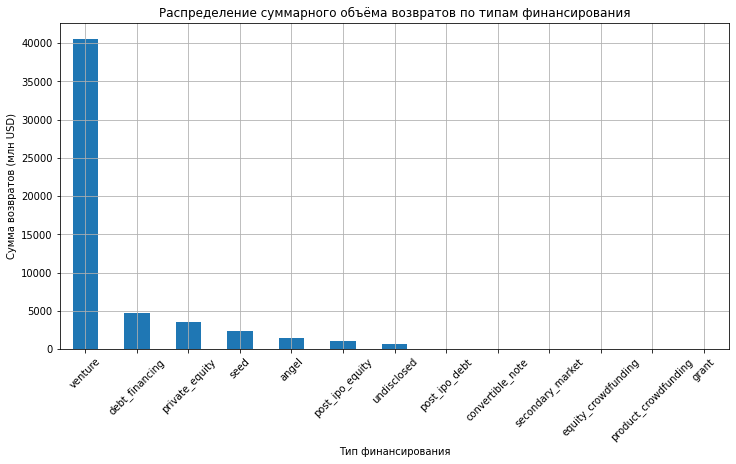

In [38]:
# Строим столбчатую диаграмму

cb_returns.sum().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12, 6),
    title='Распределение суммарного объёма возвратов по типам финансирования',
    grid=True,
    rot=45)
plt.ylabel('Сумма возвратов (млн USD)')
plt.xlabel('Тип финансирования')
plt.show()

In [39]:
# Выводим суммы возврата по типам финансирования

print(cb_returns.sum().sort_values(ascending=False))

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64


Анализ типов финансирования показал, что лидером по всем параметрам является venture - 80% всего объема вложений, 45% от всех использований и 40.6 млрд USD суммарных возвратов. `Seed` занимает второе место по популярности (30.8%), однако его доля по объему вложений существенно ниже (5.71%), та же ситуация у `angel`, доля записей 7.14%, но доля объёма всего (1.53%). Противоположная ситуация у private_equity и debt_financing доля их записей (1.54% и 7.73%) схожа или выше в сравнении с долей объема инвестиций (3.01% и  5.02%). Также они показывают высокую долю возвратов от вложений 75% и 59% соответственно. Grant единственный тип с нулевым возвратом (0 USD), что соответствует его природе — гранты не предполагают возврата средств.

In [40]:
# Создаем столбец со средним объемом за раунд

cb_investments['avg_round'] = cb_investments['funding_total_usd'] / cb_investments['funding_rounds']
cb_investments['avg_round']

0         1250000.0
1         2000000.0
2          400000.0
3         6155000.0
4        20000000.0
            ...    
33528     3000000.0
33529      494233.0
33530      510000.0
33531      400000.0
33532    26346227.0
Name: avg_round, Length: 33473, dtype: Float64

In [41]:
# Выводим объем среднего раунда по годам

cb_investments['year'] = cb_investments['mid_funding_at'].dt.year
dynanic_finance_per_year = cb_investments.groupby('year')['avg_round'].median()
dynanic_finance_per_year

year
2000         2460000.0
2001         2368582.0
2002    3616666.666667
2003         1521966.1
2004         3375000.0
2005         4628875.0
2006         3960000.0
2007         2900000.0
2008         2250000.0
2009    1583333.333333
2010         1300000.0
2011          900000.0
2012          750000.0
2013          625000.0
2014          662634.0
Name: avg_round, dtype: Float64

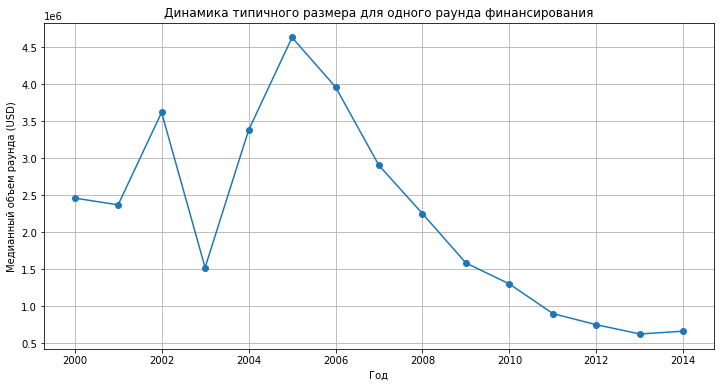

In [42]:
# Строим линейчатую диаграмму

dynanic_finance_per_year.plot(
    kind='line',
    figsize=(12, 6),
    title='Динамика типичного размера для одного раунда финансирования',
    grid=True,
    marker='o')
plt.ylabel('Медианный объем раунда (USD)')
plt.xlabel('Год')
plt.show()

In [43]:
# Выводим количество раундов по годам

dynanic_total_rounds_per_year = cb_investments.groupby('year')['funding_rounds'].sum()
dynanic_total_rounds_per_year

year
2000      109.0
2001       58.0
2002       97.0
2003      120.0
2004      169.0
2005      931.0
2006     1825.0
2007     2820.0
2008     3624.0
2009     4472.0
2010     5975.0
2011     7368.0
2012     9312.0
2013    12320.0
2014     6343.0
Name: funding_rounds, dtype: float64

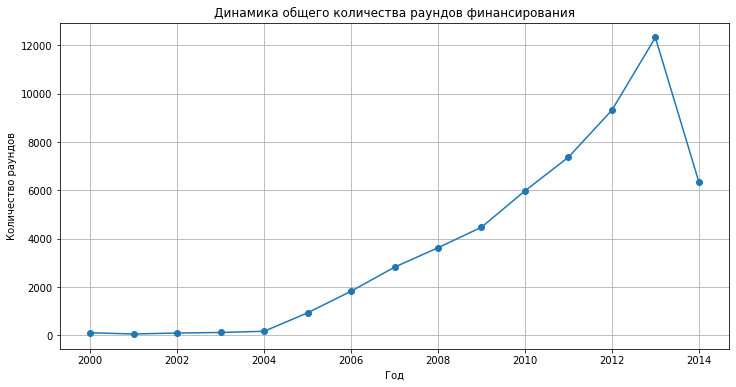

In [44]:
# Строим линейчатую диаграмму

dynanic_total_rounds_per_year.plot(
    kind='line',
    figsize=(12, 6),
    title='Динамика общего количества раундов финансирования',
    grid=True,
    marker='o')
plt.ylabel('Количество раундов')
plt.xlabel('Год')
plt.show()

На основе полученных результатов можно ответь на вопросы:

В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?
- В 2005 году типичный размер одного раунда был максимальный и составил 4.6 млн USD.

Какая тенденция в 2014 году?
- По размеру типичного раунда — небольшой рост относительно 2013 года (662 тыс. против 625 тыс.), но в целом продолжается долгосрочный тренд снижения медианного размера раунда начавшийся с 2005 года.
- По количеству раундов — зафиксирован большой спад (6343 против 12320 в 2013), однако данные по 2014 считаются не до конца полными.

В качестве вывода можно сказать, что по размеру финансирования можно видеть **убывающий тренд** начиная с 2005 и идущего вплоть до 2014 года: **4.6 млн USD в 2005 и 625 тыс. USD в 2014 году**., а количество раундов напротив показывает **рост** с 2000 по 2013 год — **с 109 до 12 320 раундов**. Такая связь может говорить о том, что инвесторы стали более избирательными и осторожными в своих вложениях, они выбирают большое количество маленьких стартапов и распределяют свои средства равномерно, чтобы с меньшей вероятностью потерять их.

In [45]:
# Выводим уникальные сегменты
mass_segments = cb_investments[(cb_investments['market'] != 'mid') & (cb_investments['market'] != 'niche')]
mass_segments['market'].unique()

array(['advertising', 'analytics', 'apps', 'automotive', 'big data',
       'biotechnology', 'clean technology', 'cloud computing',
       'consulting', 'curated web', 'design', 'e-commerce', 'education',
       'enterprise software', 'entertainment', 'fashion', 'finance',
       'games', 'hardware + software', 'health and wellness',
       'health care', 'hospitality', 'internet', 'manufacturing',
       'marketplaces', 'medical', 'messaging', 'mobile', 'music',
       'networking', 'news', 'nonprofits', 'photography',
       'public relations', 'real estate', 'saas', 'search', 'security',
       'semiconductors', 'social media', 'social network media',
       'software', 'sports', 'startups', 'technology', 'travel', 'video',
       'web hosting'], dtype=object)

In [46]:
# Строим сводную таблицу

pivot_table = mass_segments.groupby(['year', 'market'])['funding_total_usd'].sum().unstack()
pivot_table

market,advertising,analytics,apps,automotive,big data,biotechnology,clean technology,cloud computing,consulting,curated web,design,e-commerce,education,enterprise software,entertainment,fashion,finance,games,hardware + software,health and wellness,health care,hospitality,internet,manufacturing,marketplaces,medical,messaging,mobile,music,networking,news,nonprofits,photography,public relations,real estate,saas,search,security,semiconductors,social media,social network media,software,sports,startups,technology,travel,video,web hosting
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000,14470000,14822803,<NA>,<NA>,<NA>,<NA>,<NA>,11500000,4500000,1000000,<NA>,32879052,<NA>,4711445,100000,<NA>,15000000,21728774,<NA>,11900000,16000000,<NA>,10000000,56659310,<NA>,24000000,<NA>,10000000,<NA>,<NA>,<NA>,6500000,<NA>,<NA>,2500000,<NA>,2001000,20211700,<NA>,<NA>,<NA>,31732640,<NA>,<NA>,<NA>,50230,<NA>,95343090
2001,8778321,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,305000,<NA>,8800000,200000,2180175,<NA>,<NA>,<NA>,5000000,<NA>,<NA>,125000,<NA>,<NA>,2368582,105000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,26380000,101727992,650000,<NA>,27811352,<NA>,<NA>,22160000,<NA>,<NA>,15000000
2002,24500000,7500000,<NA>,<NA>,<NA>,<NA>,34390435,<NA>,<NA>,4650000,<NA>,3000000,1469542,52100995,<NA>,<NA>,<NA>,5025000,8000000,795650,20309671,<NA>,1100000,<NA>,<NA>,<NA>,10000000,11654597,<NA>,<NA>,1000000,<NA>,<NA>,<NA>,5275000,2000000,<NA>,61714000,<NA>,<NA>,<NA>,101026395,200000,<NA>,11000000,<NA>,<NA>,<NA>
2003,10500000,3840000,<NA>,4530000,<NA>,85531178,50352939,<NA>,<NA>,2550000,<NA>,<NA>,2500000,7669661,<NA>,9800000,25320000,11348830,12200000,3414041,<NA>,<NA>,<NA>,4269608,<NA>,<NA>,<NA>,8010058,<NA>,<NA>,1000000,<NA>,7100000,<NA>,6292200,<NA>,5000000,13650000,28000000,5000,<NA>,66086037,<NA>,<NA>,<NA>,<NA>,5000000,<NA>
2004,6000000,3000000,<NA>,<NA>,<NA>,97184859,50427954,<NA>,<NA>,27050000,<NA>,1505741,1350000,4500000,<NA>,<NA>,<NA>,38150000,14775000,<NA>,22219087,<NA>,10500000,3000000,<NA>,<NA>,13300000,69822132,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,10800000,68350000,88782797,6850000,<NA>,140823795,<NA>,<NA>,1750000,10230000,14704000,27000000
2005,127196022,79014044,<NA>,22500000,<NA>,480063583,19420000,<NA>,44862000,53450000,9300000,10568620,4751000,320413544,10000000,<NA>,48235001,86626921,280865552,30210000,111091410,1020480,1775000,61770000,<NA>,11090000,115917020,219894870,9970000,<NA>,9590000,17051520,7000000,79695875,250000,5240000,11800000,333759701,586220751,14780000,5200000,993076581,1882200,<NA>,50728425,27830000,6470551,483332632
2006,299299458,139701311,1310600,12660000,<NA>,903500543,131473889,9951809,23965548,164673698,707000,111222710,9511823,828288298,1800000,2620000,185839768,289892138,411754024,20770000,623056656,14655808,5000,163957751,<NA>,20250000,145133772,347275817,56466885,26889850,37116568,12880000,6686406,38600000,2080000,4791121,37821719,237943300,1227940797,60169880,5245100,1646868624,7000000,<NA>,22791000,11700000,35171772,649959267
2007,556704331,98829000,<NA>,37712601,7780000,1704078338,749711239,20354343,70346345,314704515,10800000,87784386,30283001,955973554,31224025,2000000,371704739,563631628,492471382,66828401,806054641,13547173,4495379,147726051,4145720,2100000,75270099,405971659,61033838,43745721,60941043,200000,10115000,28510000,33220000,14652595,49639551,396996223,1616604148,89022516,24104021,1686115571,16401580,<NA>,180190209,13950000,85150644,361121449
2008,622673464,208077840,4300000,59478635,2452515,1716033000,3165808492,44375000,19061080,336500027,5944302,177398187,85012747,991664296,33600000,34246883,314876377,435172418,298931267,17467779,1029156722,6544195,23412964,173054260,2710000,28812744,67854600,550375090,50248570,30807000,87416014,7110739,20549322,33295618,46613100,27226900,59304296,453928952,1107199296,76034534,10998076,1365005648,9554790,5010387,277726238,54905631,37865177,781623731


In [47]:
# Выводим сегменты, которые увеличили объем финансов в сравнении с 2013

sorted_cols = []
for segment in pivot_table.columns:
    if pivot_table[segment][2014] > pivot_table[segment][2013]:
        sorted_cols.append(segment)

print(sorted_cols)

['apps', 'big data', 'design', 'internet', 'manufacturing', 'medical', 'real estate', 'saas', 'startups', 'technology']


In [48]:
# Строим отсортированную сводную таблицу

table_sorted_pivot = pivot_table[sorted_cols]
table_sorted_pivot

market,apps,big data,design,internet,manufacturing,medical,real estate,saas,startups,technology
year,,,,,,,,,,
2000,<NA>,<NA>,<NA>,10000000,56659310,24000000,2500000,<NA>,<NA>,<NA>
2001,<NA>,<NA>,<NA>,<NA>,2368582,<NA>,<NA>,<NA>,<NA>,22160000
2002,<NA>,<NA>,<NA>,1100000,<NA>,<NA>,5275000,2000000,<NA>,11000000
2003,<NA>,<NA>,<NA>,<NA>,4269608,<NA>,6292200,<NA>,<NA>,<NA>
2004,<NA>,<NA>,<NA>,10500000,3000000,<NA>,<NA>,<NA>,<NA>,1750000
2005,<NA>,<NA>,9300000,1775000,61770000,11090000,250000,5240000,<NA>,50728425
2006,1310600,<NA>,707000,5000,163957751,20250000,2080000,4791121,<NA>,22791000
2007,<NA>,7780000,10800000,4495379,147726051,2100000,33220000,14652595,<NA>,180190209
2008,4300000,2452515,5944302,23412964,173054260,28812744,46613100,27226900,5010387,277726238


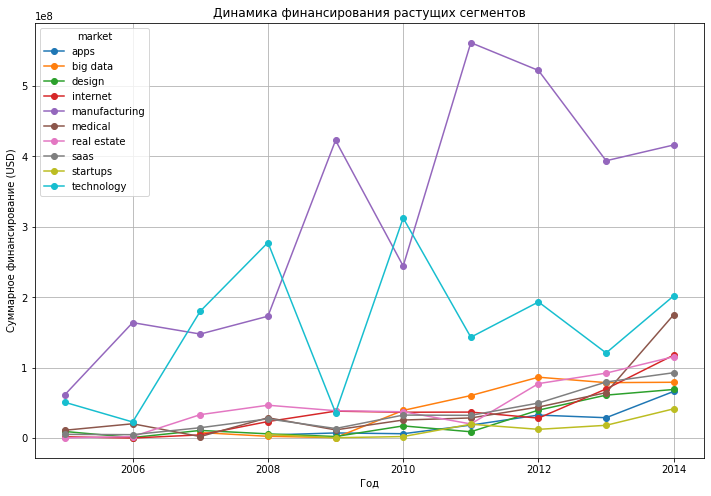

In [49]:
# Строим линейчатую диаграмму

table_sorted_pivot.loc[2005:2014].astype('float64').plot(
    kind='line',
    figsize=(12, 8),
    title='Динамика финансирования растущих сегментов',
    grid=True,
    marker='o')
plt.ylabel('Суммарное финансирование (USD)')
plt.xlabel('Год')
plt.show()

In [50]:
# Выводим столбцы с 2005 года

print(table_sorted_pivot.loc[2005:2014])

market      apps  big data    design   internet  manufacturing    medical  \
year                                                                        
2005        <NA>      <NA>   9300000    1775000       61770000   11090000   
2006     1310600      <NA>    707000       5000      163957751   20250000   
2007        <NA>   7780000  10800000    4495379      147726051    2100000   
2008     4300000   2452515   5944302   23412964      173054260   28812744   
2009     7219000    597375   2150144   38195773      422862531   11566200   
2010     6123779  39233297  17239975   36657500      244329661   25590338   
2011    18374071  60369158   8899967   36859032      561639285   28540962   
2012    32601125  86413341  39630692   28288685      522205168   44039600   
2013    28868621  78698922  60958835   69732096      393936634   64469424   
2014    66237730  79232600  68988516  117830756      416332314  175236064   

market  real estate      saas  startups  technology  
year                 

Среди растущих сегментов наиболее быстрый и уверенный рост показывают `medical`, у них финансирование выросло с **11 млн в 2005 до 175 млн в 2014**, и `internet`, с **1.8 млн до 117 млн**. На протяжении всего периода они показывают наиболее стабильный рост в финансировании.
Также можно выделить сегменты `big data` и `saas`, за крайние интервалы периода их объемы финансирования кратно увеличились и составляют **79.2 млн и 92.8 млн** соответственно.
`Technology` и `manufacturing` наиболее крупные по объёму, но менее стабильные - по всему периоду график скачкообразен. `Apps` и `startups` наименьшие по объему, но у них наблюдается заметный рост в 2014 году.

Взяли данные с 2005 года, так как в предыдущие годы много Nan, которые искажают график.

In [51]:
# Выводим по годам суммы по всем типам финансирования

invested_by_year = cb_investments.groupby('year')[fin_columns].sum()
invested_by_year

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.672414e+07,3.261576e+08,0.0,112202640.0,0.0,1.400000e+07,24086333.0,293114.0,0.000000e+00,3467747.0,0.0,7718867.0,0.0
2001,2.667675e+06,2.106088e+08,0.0,36596784.0,1500000.0,2.579217e+06,1000000.0,100000.0,0.000000e+00,0.0,0.0,0.0,0.0
2002,1.046519e+07,3.066985e+08,0.0,42323731.0,0.0,1.530967e+07,3000000.0,0.0,7.500000e+06,300000.0,0.0,0.0,0.0
2003,1.439336e+07,3.690042e+08,0.0,10280000.0,0.0,1.050000e+06,5629661.0,16850717.0,0.000000e+00,0.0,0.0,0.0,0.0
2004,1.785473e+07,6.598996e+08,0.0,58565215.0,0.0,2.881662e+07,11013741.0,10363600.0,0.000000e+00,0.0,0.0,0.0,0.0
2005,3.420950e+07,4.789195e+09,0.0,6218608.0,0.0,1.017207e+08,60914621.0,6266481.0,5.000000e+06,4796022.0,0.0,0.0,0.0
2006,6.616983e+07,8.984136e+09,0.0,58175263.0,10702385.0,1.365484e+08,70636153.0,6147500.0,1.758660e+07,0.0,0.0,0.0,0.0
2007,1.912265e+08,1.203245e+10,0.0,109649902.0,14116788.0,2.086016e+08,199202441.0,34237779.0,1.504967e+08,12000000.0,0.0,0.0,0.0
2008,2.974930e+08,1.420284e+10,0.0,117578346.0,24482809.0,4.271521e+08,248288307.0,23485347.0,1.917563e+08,36000000.0,0.0,0.0,1000000.0


In [52]:
# Нормалируем, чтобы не было ошибки деления на 0 и убираем выбросы

normalized = (cb_returns * 1000000) / (invested_by_year  + 1e-60)
normalized[normalized > 3] = float('nan')
normalized

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.998557,0.169857,0.000000,0.697042,0.000000,0.618571,0.266956,0.0,0.000000,0.271069,0.000000,0.025911,0.000000
2001,1.079592,0.111534,0.000000,0.587483,0.006667,1.740838,1.180000,0.0,0.000000,NaN,0.000000,NaN,0.000000
2002,0.629707,0.682820,0.000000,0.608878,NaN,0.223388,1.136667,0.0,0.201333,1.133333,0.000000,NaN,0.000000
2003,0.537748,0.633760,0.000000,0.914397,NaN,1.038095,0.605720,0.0,NaN,NaN,0.000000,NaN,0.000000
2004,0.556155,0.842401,0.000000,0.566719,NaN,0.470215,0.833504,0.0,NaN,NaN,0.000000,NaN,0.000000
2005,0.777562,0.548927,0.000000,1.529281,NaN,0.344964,0.509894,0.0,0.480000,0.731857,0.000000,NaN,0.000000
2006,0.934111,0.345073,NaN,0.803434,0.166318,0.829083,0.675999,0.0,0.947881,NaN,0.000000,NaN,0.000000
2007,0.368202,0.297975,NaN,0.504971,0.228097,0.602488,0.825843,0.0,0.590113,2.030000,0.000000,NaN,0.000000
2008,0.301587,0.191301,NaN,0.348874,0.069845,0.930676,0.414156,0.0,0.679925,2.341111,0.000000,NaN,0.000000


In [53]:
# Выводим описание нормализованной таблицы

display(normalized.describe())

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
count,15.000000,15.000000,12.000000,15.000000,11.000000,15.000000,15.000000,15.0,13.000000,11.000000,15.000000,5.000000,15.000000
mean,0.547746,0.396079,0.026741,0.563429,0.073938,0.699157,0.694996,0.0,0.597300,1.114408,0.143559,0.222828,0.012372
std,0.292642,0.244644,0.039785,0.345043,0.066787,0.408881,0.287364,0.0,0.350918,0.744182,0.297196,0.364787,0.023245
min,0.152272,0.111534,0.000000,0.162360,0.000000,0.223388,0.266956,0.0,0.000000,0.268531,0.000000,0.006218,0.000000
25%,0.300318,0.195861,0.000000,0.313412,0.047415,0.460961,0.513169,0.0,0.480000,0.614049,0.000000,0.012800,0.000000
50%,0.537748,0.317874,0.003705,0.566719,0.055642,0.509240,0.615945,0.0,0.645955,0.805595,0.000000,0.025911,0.000000
75%,0.703634,0.591344,0.035075,0.652960,0.070958,0.879879,0.829674,0.0,0.797870,1.691642,0.115300,0.212068,0.012781
max,1.079592,0.842401,0.118041,1.529281,0.228097,1.740838,1.204979,0.0,1.136350,2.341111,0.980645,0.857143,0.068571


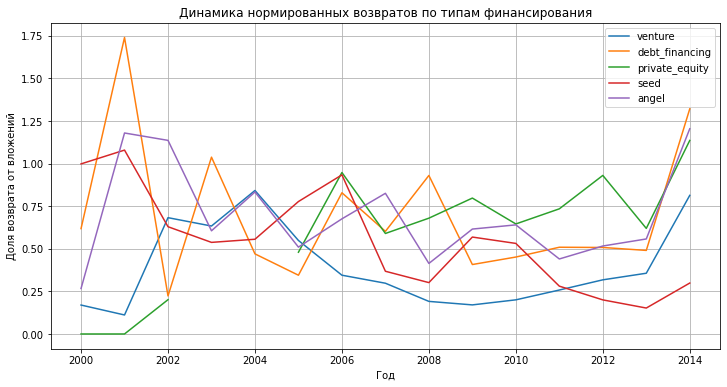

In [54]:
# Строим линейчатую диаграмму

cols = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

normalized[cols].plot(
    kind='line',
    figsize=(12, 6),
    title='Динамика нормированных возвратов по типам финансирования',
    grid=True
    )
plt.ylabel('Доля возврата от вложений')
plt.xlabel('Год')
plt.show()

In [55]:
# Смотрим данные по конкретным типам финансирования

normalized[cols]

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,0.169857,0.618571,0.000000,0.998557,0.266956
2001,0.111534,1.740838,0.000000,1.079592,1.180000
2002,0.682820,0.223388,0.201333,0.629707,1.136667
2003,0.633760,1.038095,NaN,0.537748,0.605720
2004,0.842401,0.470215,NaN,0.556155,0.833504
2005,0.548927,0.344964,0.480000,0.777562,0.509894
2006,0.345073,0.829083,0.947881,0.934111,0.675999
2007,0.297975,0.602488,0.590113,0.368202,0.825843
2008,0.191301,0.930676,0.679925,0.301587,0.414156


Из графика видно что `venture` показывает наиболее плавный рост возвратов начиная с 2009 года и достигает максимума в 2014 **(0.81)**. `Debt_financing` и `private_equity` также держатся на высоком уровне и растут к 2014 году до значений, превышающих вложения. `Seed` напротив снижается на протяжении всего периода — с 1.0 в начале до 0.3 в 2014. `Angel` также показал рост до **1.2** к 2014 году, хотя на протяжении всего периода был достаточно волатилен. Таким образом наиболее устойчивый рост показывают `venture` (его стоит рассматривать в долгосрочной перспективе так как тренд восходящий, но окупаемость пока меньше единицы) и `debt_financing`.

**1. Рекомендации**

Представляя себя на месте заказчика в 2015 году, на основе проведённого анализа я бы рекомендовал обратить внимание на сегменты `medical` и `internet`, они оба показывают устойчивый рост финансирования на протяжении всего рассматриваемого периода без значительных провалов, что говорит о большой и растущей вовлеченности инвесторов к этим направлениям. Также можно рассмотреть достаточно новые направления `big data` и `saas`, они показывают отличный рост в 2010-2014 годах и имеют большой потенциал для роста в будущем.
В качестве типа финансирования я бы рекомендовал `debt_financing` — в 2014 году он показывает возврат превышающий вложения **(1.32)**, что говорит о его высокой эффективности. `Venture` также **растёт с 2009 года**, однако пока не достиг полной окупаемости **(0.81 в 2014)** — его стоит рассматривать как долгосрочную перспективу, так как тренд восходящий. `Private_equity` тоже можно рассмотреть, возврат **1.14** в 2014 году говорит о том, что вложения в среднем окупаются.

**2. Итоги проекта**

В ходе работы были выполнены загрузка и предобработка двух датасетов `cb_investments` и `cb_returns`, в них были исправлены типы данных, обработаны пропуски, удалены дубликаты и нормализованы текстовые столбцы для обработки неявных дубликатов. Компании были разделены на группы по срокам финансирования и сегментам рынка, выявлены и удалены аномальные значения методом IQR по каждому сегменту отдельно, после чего датасет был отфильтрован по годам с достаточным количеством данных. В конце была проанализирована динамика финансирования по годам и сегментам, а также рассчитаны нормированные значения возвратов по типам финансирования.

Основные выводы согласуются между собой — `venture` лидируют на рынке как по объёму вложений, так и по популярности, сегменты `medical` и `internet` показывают стабильный рост на протяжении всего периода, а `debt_financing` и `private_equity` выглядят наиболее эффективными по соотношению вложений и возвратов. Следует не забывать, что данные за 2014 году были не полные и обрывались в начале декабря, исходя из этого, какие-то моменты могут быть не совсем точными.